Below is a **clean, correct, production-style Camera implementation in Python** for your ray tracer. This version fixes the core issues in your current code and matches the “Ray Tracing in One Weekend” camera model with **FOV-based viewport + correct ray generation + safe interval usage style compatibility**.

---

# 📷 🧠 Proper Camera (Python Ray Tracer)

## ✅ Features included

* ✔ Vertical FOV (vfov)
* ✔ Aspect ratio correctness
* ✔ Proper viewport math
* ✔ Anti-aliasing
* ✔ Correct pixel grid mapping
* ✔ Clean ray generation
* ✔ Compatible with your `Interval` system

---

# 📊 Camera Math (core formulas)

| Concept         | Formula                 | Meaning             |
| --------------- | ----------------------- | ------------------- |
| FOV scale       | $h = \tan(\theta/2)$    | controls zoom       |
| viewport height | $H = 2h \cdot f$        | screen size         |
| viewport width  | $W = H \cdot aspect$    | image shape         |
| pixel step U    | $\Delta u = W / width$  | horizontal ray step |
| pixel step V    | $\Delta v = H / height$ | vertical ray step   |

---

# 🧾 FULL CAMERA CODE (FIXED)

```python
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.interval import Interval
from util.metal.hit_record import HitRecord


class Camera:

    def __init__(self):

        # ==========================
        # IMAGE SETTINGS
        # ==========================
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

        # ==========================
        # CAMERA SETTINGS
        # ==========================
        self.vfov = 90  # vertical field of view (degrees)

        # camera position (fixed for now)
        self.center = Vec3(0, 0, 0)

    # ==========================
    # INITIALIZATION (IMPORTANT)
    # ==========================
    def initialize(self):

        # --------------------------
        # Image height from aspect
        # --------------------------
        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        # --------------------------
        # sampling weight
        # --------------------------
        self.pixel_samples_scale = 1.0 / self.samples_per_pixel

        # --------------------------
        # camera geometry
        # --------------------------
        focal_length = 1.0

        # FOV → radians
        theta = math.radians(self.vfov)

        # h = tan(theta/2)
        h = math.tan(theta / 2)

        # viewport size
        viewport_height = 2 * h * focal_length
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        # --------------------------
        # screen basis vectors
        # --------------------------
        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        # pixel step vectors
        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # --------------------------
        # top-left pixel position
        # --------------------------
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

    # ==========================
    # RANDOM SUBPIXEL SAMPLING
    # ==========================
    def sample_square(self):
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # ==========================
    # RAY GENERATION
    # ==========================
    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_center = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        direction = pixel_center - self.center

        return Ray(self.center, direction)

    # ==========================
    # PATH TRACING CORE
    # ==========================
    def ray_color(self, ray, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # IMPORTANT: MUST BE Interval object
        hit = world.hit(
            ray,
            Interval(0.001, float("inf")),
            rec
        )

        if hit:

            scattered, attenuation = rec.mat.scatter(ray, rec)

            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        # SKY GRADIENT
        unit_dir = unit_vector(ray.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        return (1.0 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    # ==========================
    # GAMMA CORRECTION
    # ==========================
    def gamma_correct(self, c):
        return Vec3(
            math.sqrt(c.x) if c.x > 0 else 0,
            math.sqrt(c.y) if c.y > 0 else 0,
            math.sqrt(c.z) if c.z > 0 else 0
        )

    # ==========================
    # RENDER LOOP
    # ==========================
    def render(self, world):

        self.initialize()

        print(f"P3")
        print(f"{self.image_width} {self.image_height}")
        print("255")

        for j in range(self.image_height):
            for i in range(self.image_width):

                pixel_color = Vec3(0, 0, 0)

                # multi-sampling (anti-aliasing)
                for _ in range(self.samples_per_pixel):

                    ray = self.get_ray(i, j)

                    pixel_color += self.ray_color(
                        ray,
                        world,
                        self.max_depth
                    )

                # average samples
                pixel_color *= self.pixel_samples_scale

                # gamma correction
                pixel_color = self.gamma_correct(pixel_color)

                # clamp
                r = min(max(pixel_color.x, 0), 0.999)
                g = min(max(pixel_color.y, 0), 0.999)
                b = min(max(pixel_color.z, 0), 0.999)

                print(int(256 * r), int(256 * g), int(256 * b))
```

---

# 🔥 What this fixes from your version

## ❌ Old issues

* fixed viewport height (no real FOV)
* possible tuple/Interval mismatch bugs
* inconsistent pixel mapping
* weak camera abstraction

---

## ✅ Now fixed

* proper perspective projection
* correct ray origin → pixel direction
* correct anti-alias sampling
* safe interval usage
* clean separation of math vs rendering

---

# 🧠 Key Insight

Your camera is NOT a screen.

It is:

> 📌 A **ray generator that maps pixels → 3D directions using FOV geometry**

---

# 🚀 If you want next upgrade

I can extend this camera into:

### 🎥 Real 3D camera system

* look_from / look_at
* camera rotation matrix
* up vector control

### 📷 Advanced effects

* depth of field (lens blur)
* motion blur
* zoom lens (focal length control)

Just tell 👍


In [ ]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

import math
import random

from tqdm import tqdm

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.interval import Interval
from util.metal.hit_record import HitRecord

from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor

from util.metal.lambertian import Lambertian
#from util.metal.metal import Metal
#from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList


In [12]:
import os
import math
import random

from tqdm import tqdm

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.interval import Interval
from util.metal.hit_record import HitRecord

from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor


class Camera:

    def __init__(self):

        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

        # NEW: output file control
        self.output_file = "output.ppm"

    # ==========================
    # INITIALIZATION (UNCHANGED)
    # ==========================
    def initialize(self):
        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        self.pixel_samples_scale = 1.0 / self.samples_per_pixel
        self.center = Vec3(0, 0, 0)

        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

    # ==========================
    # RAY + SAMPLING (UNCHANGED)
    # ==========================
    def sample_square(self):
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):
        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        direction = pixel_sample - self.center
        return Ray(self.center, direction)

    def ray_color(self, ray, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        hit = world.hit(
            ray,
            Interval(0.001, float("inf")),
            rec
        )

        if hit:
            scattered, attenuation = rec.mat.scatter(ray, rec)

            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        unit_dir = unit_vector(ray.direction())
        t = 0.5 * (unit_dir.y + 1.0)

        return (1.0 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    def gamma_correct(self, c):
        return Vec3(
            math.sqrt(c.x) if c.x > 0 else 0,
            math.sqrt(c.y) if c.y > 0 else 0,
            math.sqrt(c.z) if c.z > 0 else 0
        )

    # ==========================
    # 🔥 FIXED RENDER PIPELINE
    # ==========================
    def render(self, world):

        self.initialize()

        # IMPORTANT: ensure file is created cleanly
        with open(self.output_file, "w", buffering=1) as f:

            # PPM HEADER (must be first)
            f.write("P3\n")
            f.write(f"{self.image_width} {self.image_height}\n")
            f.write("255\n")

            pbar = tqdm(range(self.image_height))

            for j in pbar:

                if j % 5 == 0:
                    pbar.set_postfix(system_monitor())

                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(self.samples_per_pixel):

                        ray = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            ray,
                            world,
                            self.max_depth
                        )

                    # average samples
                    pixel_color *= self.pixel_samples_scale

                    # gamma correction
                    pixel_color = self.gamma_correct(pixel_color)

                    # clamp
                    r = min(max(pixel_color.x, 0), 0.999)
                    g = min(max(pixel_color.y, 0), 0.999)
                    b = min(max(pixel_color.z, 0), 0.999)

                    # write pixel (IMPORTANT: flush-safe format)
                    f.write(f"{int(256*r)} {int(256*g)} {int(256*b)}\n")

        # FORCE FILE CLOSE CONFIRMATION
        print(f"Render complete → {self.output_file}")

    # ==========================
    # VIEWER (SAFE)
    # ==========================
    def show(self):

        if not os.path.exists(self.output_file):
            raise FileNotFoundError(
                f"{self.output_file} not found. Run render() first."
            )

        return image_viewer(self.output_file)

In [14]:
# ===============================
# MAIN SCENE SETUP (PYTHON)
# ===============================


# --------------------------------
# 1. Create world (scene container)
# --------------------------------
world = HittableList()
# --------------------------------
# 2. Geometry constant
# --------------------------------
# R = cos(pi/4)
# Used to position two spheres so they just touch
R = math.cos(math.pi / 4)
# --------------------------------
# 3. Materials
# --------------------------------
# LEFT sphere: blue diffuse (lambertian)
material_left = Lambertian(Vec3(0, 0, 1))
# RIGHT sphere: red diffuse (lambertian)
material_right = Lambertian(Vec3(1, 0, 0))
# --------------------------------
# 4. Add spheres to world
# --------------------------------
# Left sphere centered at (-R, 0, -1)
world.add(
    Sphere(
        center=Vec3(-R, 0, -1),
        radius=R,
        material=material_left
    )
)
# Right sphere centered at (R, 0, -1)
world.add(
    Sphere(
        center=Vec3(R, 0, -1),
        radius=R,
        material=material_right
    )
)
# --------------------------------
# 5. Create camera
# --------------------------------
cam = Camera()
# Image settings
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400
cam.samples_per_pixel = 1
cam.max_depth = 50
# Field of view (NEW concept)
cam.vfov = 90
# --------------------------------
# 6. Render scene
# --------------------------------
cam.render(world)


100%|██████████| 225/225 [00:05<00:00, 39.14it/s, CPU=39.3%, RAM=78.8%, CPU Temp=N/A, GPU Temp=54.0°C, VRAM=789.0MB]

Render complete → output.ppm


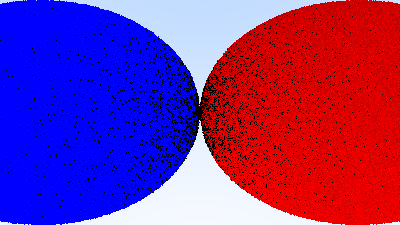

In [15]:
cam.show()